<a href="https://colab.research.google.com/github/Tanish-k08/CM23021-Pattern_Recognition/blob/main/CM23021_PR_prac7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

       NUMBER PLATE VALIDATION


,Number_Plate,Syntactic,Grammar
0,MH12AB1234,True,True
1,DL01CA5678,True,True
2,KA05MK1234,True,True
3,MH20CD4567,True,True
4,M12AB1234,False,False
5,MH12AB123,False,False



PHOTO OPTION
1 - Upload my own number plate photo
2 - Use sample photo

Enter 1 or 2: 1

Upload your number plate image:


Saving images.jpg to images.jpg

Uploaded Number Plate Photo:


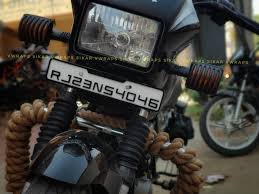


Enter the number written on the uploaded plate.
Number Plate: RJ23NS4046

           FINAL RESULT
Plate       : RJ23NS4046
Syntactic   : VALID
Grammar     : VALID

FINAL DECISION: VALID NUMBER PLATE

             PARSE TREE

PLATE
├── STATE
│   ├── R
│   └── J
│
├── RTO
│   ├── 2

│   └── 3
│
├── SERIES
│   ├── N
│   └── S
│
└── NUMBER
    ├── 4
    ├── 0
    ├── 4
    └── 6


In [ ]:

import re
import pandas as pd
from PIL import Image
from IPython.display import display
from google.colab import files
plates = [
    "MH12AB1234",
    "DL01CA5678",
    "KA05MK1234",
    "MH20CD4567",
    "M12AB1234",
    "MH12AB123"
]

df = pd.DataFrame({
    "Number_Plate": plates
})

pattern = r"^[A-Z]{2}[0-9]{1,2}[A-Z]{1,3}[0-9]{4}$"

def syntactic_check(plate):
    return bool(re.fullmatch(pattern, plate))


df["Syntactic"] = df["Number_Plate"].apply(syntactic_check)


def grammar_check(plate):

    if not re.fullmatch(
        r"[A-Z]{2}[0-9]{1,2}[A-Z]{1,3}[0-9]{4}",
        plate
    ):
        return False

    return True


df["Grammar"] = df["Number_Plate"].apply(grammar_check)

print("==========================================")
print("       NUMBER PLATE VALIDATION")
print("==========================================")

display(df)

print("\n==========================================")
print("PHOTO OPTION")
print("==========================================")

print("1 - Upload my own number plate photo")
print("2 - Use sample photo")

choice = input("\nEnter 1 or 2: ")


if choice == "1":

    print("\nUpload your number plate image:")
    uploaded = files.upload()

    filename = list(uploaded.keys())[0]

    image = Image.open(filename)

    print("\nUploaded Number Plate Photo:")
    display(image)

    print("\nEnter the number written on the uploaded plate.")
    plate = input("Number Plate: ").upper().replace(" ", "")



else:

    print("\nUsing sample number plate.")

    plate = "MH12AB1234"


    image = Image.new("RGB", (700, 180), "white")

    from PIL import ImageDraw, ImageFont

    draw = ImageDraw.Draw(image)

    draw.rectangle(
        (10, 10, 690, 170),
        outline="black",
        width=6
    )

    try:
        font = ImageFont.truetype(
            "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
            65
        )
    except:
        font = None

    draw.text(
        (130, 50),
        plate,
        fill="black",
        font=font
    )

    print("\nSample Number Plate Photo:")
    display(image)


plate = re.sub(r"[^A-Z0-9]", "", plate.upper())

syntactic_result = syntactic_check(plate)
grammar_result = grammar_check(plate)


print("\n==========================================")
print("           FINAL RESULT")
print("==========================================")

print("Plate       :", plate)

print(
    "Syntactic   :",
    "VALID" if syntactic_result else "INVALID"
)

print(
    "Grammar     :",
    "VALID" if grammar_result else "INVALID"
)


if syntactic_result and grammar_result:

    print("\nFINAL DECISION: VALID NUMBER PLATE")

else:

    print("\nFINAL DECISION: INVALID NUMBER PLATE")


if syntactic_result and grammar_result:

    state = plate[:2]

    remaining = plate[2:]

    rto = re.match(r"[0-9]{1,2}", remaining).group()

    remaining = remaining[len(rto):]

    series = re.match(r"[A-Z]{1,3}", remaining).group()

    number = remaining[len(series):]

    print("\n==========================================")
    print("             PARSE TREE")
    print("==========================================")

    print(f"""
PLATE
├── STATE
│   ├── {state[0]}
│   └── {state[1]}
│
├── RTO
│   ├── {rto[0]}
""")

    if len(rto) == 2:
        print(f"│   └── {rto[1]}")

    print("│")

    print("├── SERIES")

    for i, ch in enumerate(series):
        if i == len(series) - 1:
            print(f"│   └── {ch}")
        else:
            print(f"│   ├── {ch}")

    print("│")

    print("└── NUMBER")

    for i, ch in enumerate(number):
        if i == len(number) - 1:
            print(f"    └── {ch}")
        else:
            print(f"    ├── {ch}")